# XGBoost — Gradient Boosting Model
- Part A: Hyperparameter sensitivity - 4-window averaging scheme
- Part B: Window scheme comparison - 4-window averaging vs single expanding window

**Standardisation**  
For each origin and each training window, the features and target variable are standardized using only the mean and standard deviation of that training window. The same transformation is applied to the test inputs before prediction, and the predictions are converted to EUR/MWh. For consistency with the LEAR setup, features and the target variable are standardized separately within each training window. The predictions are then transformed back to EUR/MWh before evaluation.

**Hyperparameter starting point**  
The baseline configuration is taken from Lebedev et al. (2025), who tuned it using Optuna on hourly data from Germany (200 trials, random seed 42). Part A evaluates the benefit of the configuration when applied to quarter-hourly data instead, using three other configurations as comparisons. The best configuration found in Part A is used for the remainder of Part B.

# Step 1 - Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from xgboost import XGBRegressor

print("Imports OK")

Imports OK


# Step 2 - Configuration

In [2]:
split_dir  = Path("../data/split")
output_dir = Path("../data/results")

nintervals   = 96
random_state = 42

features = [
    "price_lag1d",
    "price_lag7d",
    "price_hourly_lag1d",
    "price_hourly_lag7d",
    "wind_mwh",
    "solar_mwh",
    "load_mwh",
]

target     = "price_eur_mwh"

# four training windows (days), taken from Lebedev et al.(2025)
windows = [100, 84, 56, 28]

# hyperparameter configurations to compare
# Baseline: directly from Lebedev et al.(2025), Optuna seed 42
# Config A: fewer trees, higher learning rate - faster, less risk of overfitting
# Config B: deeper trees, more data per tree - more complex patterns
# Config C: simple defaults - interpretable baseline
configs = {
    "Baseline": dict(
        n_estimators     = 444,
        learning_rate    = 0.020834136992346326,
        max_depth        = 4,
        min_child_weight = 6,
        subsample        = 0.6646124229308177,
        colsample_bytree = 0.6061035603483517,
        gamma            = 0.008910429703573388,
        reg_alpha        = 0.14968119527801219,
        reg_lambda       = 0.26277200687034197,
        random_state     = random_state,
    ),
    "Config A": dict(
        n_estimators     = 100,
        learning_rate    = 0.1,
        max_depth        = 4,
        min_child_weight = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        gamma            = 0.0,
        reg_alpha        = 0.0,
        reg_lambda       = 1.0,
        random_state     = random_state,
    ),
    "Config B": dict(
        n_estimators     = 200,
        learning_rate    = 0.05,
        max_depth        = 6,
        min_child_weight = 3,
        subsample        = 1.0,
        colsample_bytree = 1.0,
        gamma            = 0.0,
        reg_alpha        = 0.0,
        reg_lambda       = 1.0,
        random_state     = random_state,
    ),
    "Config C": dict(
        n_estimators     = 100,
        learning_rate    = 0.1,
        max_depth        = 3,
        min_child_weight = 1,
        subsample        = 1.0,
        colsample_bytree = 1.0,
        gamma            = 0.0,
        reg_alpha        = 0.0,
        reg_lambda       = 1.0,
        random_state     = random_state,
    ),
}

print(f"Configurations to compare : {len(configs)}")
print(f"Rolling windows : {windows} days")
for name in configs:
    print(f"- {name}")

Configurations to compare : 4
Rolling windows : [100, 84, 56, 28] days
- Baseline
- Config A
- Config B
- Config C


# Step 3 - Load Data

In [3]:
df = pd.read_csv(split_dir / "feature_matrix_clean.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)   #sort the  data by time and then renumber 

train_days = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "train_days.csv")["date"]]
test_days  = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "test_days.csv")["date"]]
all_days   = sorted(df["timestamp"].dt.date.unique())

n_train = len(train_days)   # 100
n_test  = len(test_days)    # 44
n_total = len(all_days)     # 144

X_all = df[features].values   # (13824, 7)
y_all = df[target].values     # (13824,)

# ground-truth prices for the test period in EUR/MWh
train_end   = n_train * nintervals
y_test_orig = y_all[train_end:].reshape(n_test, nintervals)

print(f"X_all : {X_all.shape}")
print(f"Train : {n_train} days - Test : {n_test} days")

X_all : (13824, 7)
Train : 100 days - Test : 44 days


# Step 4- Helper: standardize, fit, and predict for one window
A single function handles model standardization and fitting for each training window. The model is trained only on the training window, and the scaling parameters are used to scale the test row. The predicted value is back-transformed to the original scale of EUR/MWh.


In [4]:
# Parameters
# X_all: full feature array, shape (n_total_obs, n_features)
# y_all: full target array,  shape (n_total_obs,)
# row_star: first row of the training window
# row_end: one past the last training row (= first row of the forecast day)
# row_pred: first of the 96 rows to predict
# params: dict of XGBoost hyperparameters
# Returns: predicted prices in EUR/MWh, shape (nintervals,)
def fit_and_predict(X_all, y_all, row_start, row_end, row_pred, params, nintervals=nintervals):
    # training slice for this window
    X_tr = X_all[row_start:row_end, :]
    y_tr = y_all[row_start:row_end]

    # compute scaling statistics from this window's training data only
    mean_X = X_tr.mean(axis=0)
    std_X  = X_tr.std(axis=0)
    std_X[std_X == 0] = 1.0   # avoid division by zero for constant features

    mean_y = y_tr.mean()
    std_y  = y_tr.std()
    if std_y == 0:
        std_y = 1.0

    # standardize training data
    X_tr_sc = (X_tr - mean_X) / std_X
    y_tr_sc = (y_tr - mean_y) / std_y

    # apply the same scaling to the test row
    X_te_sc = (X_all[row_pred:row_pred + nintervals, :] - mean_X) / std_X

    # fit XGBoost in normalized space and predict
    model = XGBRegressor(**params)
    model.fit(X_tr_sc, y_tr_sc)
    pred_sc = model.predict(X_te_sc)

    # back-transform prediction to EUR/MWh
    return pred_sc * std_y + mean_y


print("Helper function defined")

Helper function defined


# Step 5 - Part A: Hyperparameter sensitivity (4-window averaging)
For each configuration, four XGBoost models are estimated for each trading day using 100, 84, 56, and 28-day windows. The final forecast is the unweighted average of the four models. Each model has its own standardization parameters.

In [5]:
config_results = {}   # stores evaluation scores 
config_preds   = {}   # stores forecast matrix 

for config_name, params in configs.items():
    print(f"\n{config_name}")

    # empty matrix to collect predictions for all test days
    all_preds = np.zeros((n_test, nintervals))

    # loop over all test days
    for i in range(n_test):
        forecast_day_idx = n_train + i            # absolute day index of the day being forecast
        row_pred = forecast_day_idx * nintervals  # first row of the 96 test observations

        # loop over the four training windows
        window_preds = []   # one prediction array per window
        for w in windows:
            row_end   = forecast_day_idx * nintervals              # first row of the forecast day
            row_start = max(forecast_day_idx - w, 0) * nintervals  # first row of this training window

            pred = fit_and_predict(
                X_all, y_all,
                row_start=row_start,
                row_end=row_end,
                row_pred=row_pred,
                params=params,
            )
            window_preds.append(pred)

        # unweighted average across the four windows
        all_preds[i, :] = np.mean(window_preds, axis=0)

    # MAE: average absolute error; RMSE: penalises large errors more heavily
    errors = y_test_orig - all_preds
    mae  = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))

    config_results[config_name] = {"MAE": round(mae, 4), "RMSE": round(rmse, 4)}
    config_preds[config_name]   = all_preds
    print(f"  -> MAE: {mae:.4f}  RMSE: {rmse:.4f} EUR/MWh")

print("\nAll configurations done")


Baseline
  -> MAE: 11.5527  RMSE: 16.2672 EUR/MWh

Config A
  -> MAE: 11.7366  RMSE: 16.4267 EUR/MWh

Config B
  -> MAE: 12.1672  RMSE: 17.2278 EUR/MWh

Config C
  -> MAE: 11.6173  RMSE: 16.5728 EUR/MWh

All configurations done


# Step 6 - Hyperparameter comparison table

In [7]:
print("XGBoost - Hyperparameter Comparison (4-window averaging)")
print(f"  {'Configuration':<38} {'MAE':>8} {'RMSE':>8}")
for name, r in config_results.items():
    print(f"  {name:<38} {r['MAE']:>8.4f} {r['RMSE']:>8.4f}")
print()

# select the configuration with the lowest MAE
best_config = min(config_results, key=lambda x: config_results[x]["MAE"])
best_params = configs[best_config]   # direct dict lookup - used in Part B

print(f"\nBest configuration (lowest MAE): {best_config}")

XGBoost - Hyperparameter Comparison (4-window averaging)
  Configuration                               MAE     RMSE
  Baseline                                11.5527  16.2672
  Config A                                11.7366  16.4267
  Config B                                12.1672  17.2278
  Config C                                11.6173  16.5728


Best configuration (lowest MAE): Baseline


# Step 7 - Part B: Window scheme comparison
The 4-window averaging is compared to the expanding window using the best configuration found in Part A for both methods. The effect of using each different window scheme is studied in isolation.


In [8]:
print(f"Window scheme comparison using {best_config}")
print(f"Running expanding-window evaluation ({n_test} test days)...")

pred_expanding = np.zeros((n_test, nintervals))

for i in range(n_test):
    forecast_day_idx = n_train + i
    row_end  = forecast_day_idx * nintervals   # expanding window always starts at row 0
    row_pred = forecast_day_idx * nintervals

    pred_expanding[i, :] = fit_and_predict(
        X_all, y_all,
        row_start=0,
        row_end=row_end,
        row_pred=row_pred,
        params=best_params,
    )

    # progress update: first day and every 10 days thereafter
    if (i + 1) % 10 == 0 or i == 0:
        print(f"  Day {i+1:>2d}/44 — trained on {forecast_day_idx} days ({row_end} observations)")

errors_exp = y_test_orig - pred_expanding
mae_exp  = float(np.mean(np.abs(errors_exp)))
rmse_exp = float(np.sqrt(np.mean(errors_exp ** 2)))

print(f"\nExpanding window -> MAE: {mae_exp:.4f}  RMSE: {rmse_exp:.4f} EUR/MWh")

Window scheme comparison using Baseline
Running expanding-window evaluation (44 test days)...
  Day  1/44 — trained on 100 days (9600 observations)
  Day 10/44 — trained on 109 days (10464 observations)
  Day 20/44 — trained on 119 days (11424 observations)
  Day 30/44 — trained on 129 days (12384 observations)
  Day 40/44 — trained on 139 days (13344 observations)

Expanding window -> MAE: 11.7695  RMSE: 16.4203 EUR/MWh


# Step 8 - Window scheme comparison table

In [11]:
best_4w = config_results[best_config]

print(f"XGBoost - Window Scheme Comparison  ({best_config})")
print(f"  {'Scheme':<30} {'MAE':>8} {'RMSE':>8}")
print()
print(f"{'4-window averaging':<30} {best_4w['MAE']:>8.4f} {best_4w['RMSE']:>8.4f}")
print(f"{'Expanding window':<30} {mae_exp:>8.4f} {rmse_exp:>8.4f}")

XGBoost - Window Scheme Comparison  (Baseline)
  Scheme                              MAE     RMSE

4-window averaging              11.5527  16.2672
Expanding window                11.7695  16.4203


## Step 9 - Forecast plot (best configuration)
Actual vs forecast prices for the first 7 days of the evaluation period (16–22 January 2026), using the best configuration with 4-window averaging

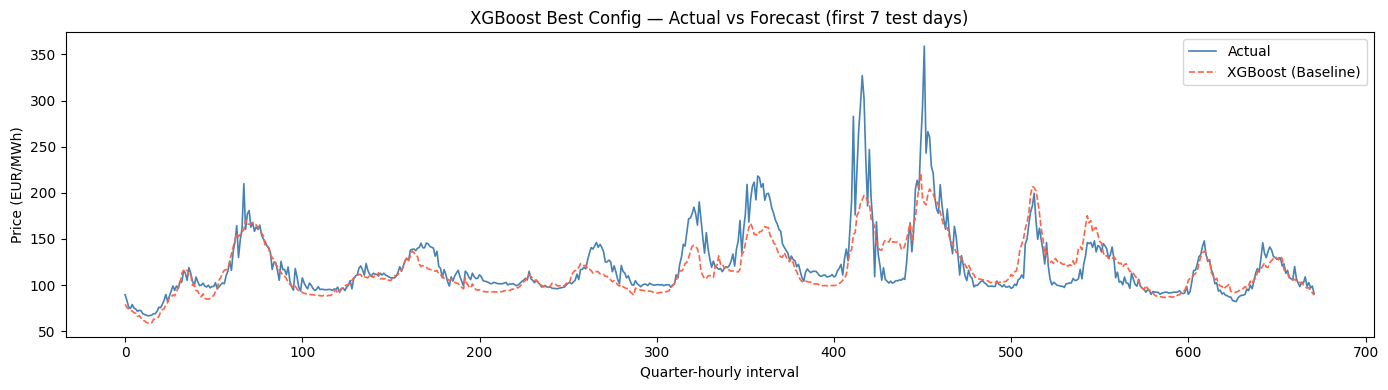

Plot saved


In [13]:
best_pred    = config_preds[best_config]
n_plot       = 7 * nintervals

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test_orig.flatten()[:n_plot],
        label="Actual", linewidth=1.2, color="steelblue")
ax.plot(best_pred.flatten()[:n_plot],
        label=f"XGBoost ({best_config})", linewidth=1.2, color="tomato", linestyle="--")
ax.set_title("XGBoost Best Config — Actual vs Forecast (first 7 test days)")
ax.set_xlabel("Quarter-hourly interval")
ax.set_ylabel("Price (EUR/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "XGBoost_forecast_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")

## Step 10 - Save results

In [14]:
best_result = config_results[best_config]

xgb_dict = {
    # identification
    "model_name"        : "XGBoost",
    # best configuration — 4-window, best config by MAE
    "best_config"       : best_config,
    "best_params"       : best_params,        # full hyperparameter dict
    "all_config_results": config_results,
    "prediction"        : best_pred,          # (n_test, 96) EUR/MWh, 4-window best
    "mae"               : best_result["MAE"],
    "rmse"              : best_result["RMSE"],
    # window scheme comparison (both use best config)
    "pred_expanding"    : pred_expanding,     # (n_test, 96) EUR/MWh
    "mae_expanding"     : mae_exp,
    "rmse_expanding"    : rmse_exp,
    # ground truth and metadata
    "y_test"            : y_test_orig,        # (n_test, 96) EUR/MWh
    "test_days"         : [str(d) for d in test_days],
}

with open(output_dir / "XGBoost.pkl", "wb") as f:
    pickle.dump([xgb_dict], f)

print(f"Saved: {output_dir / 'XGBoost.pkl'}")
print("XGBoost.ipynb complete")

Saved: ..\data\results\XGBoost.pkl
XGBoost.ipynb complete
